# Cleaning de BD Consolidada

In [1]:
import pandas as pd

In [2]:
data = pd.read_parquet("/Users/adrianmateos/Documents/RetoOctavo/data_consolidation/output/transacciones_consolidado.parquet")

print("shape datos consolidados:", data.shape)

shape datos consolidados: (1145526, 57)


In [3]:
print(data.columns)

Index(['t_folio', 't_folio_ext', 't_referencia', 't_transaccion', 't_codigo',
       't_cve_res', 't_cuarto', 't_centro_consumo', 't_fecha', 't_tra_hra',
       't_tra_mto', 't_monto', 't_impuesto', 't_impuesto2', 't_propina',
       't_carabo', 't_tra_cancelada', 't_can_dia', 't_can_mes', 't_can_hra',
       't_can_mto', 't_usuario', 't_usuario_mod', 't_num_adu', 't_num_per',
       't_noches', 't_inc_tfa', 't_observaciones', 't_timestamp', 'es_split',
       'es_renta', 'h_status', 'h_tpo_hab', 'h_tpo_hsp', 'h_seg_mer',
       'h_cod_age', 'h_tpo_plan', 'h_for_pgo', 'h_tpo_mon', 'h_num_per',
       'h_num_adu', 'h_num_men', 'h_num_noc', 'h_tfa', 'h_tfa_total',
       'h_tfa_renta', 'h_tfa_impuestos', 'h_tfa_extras', 'h_tarifa_forzada',
       'h_dep_sol', 'h_lim_cre', 'h_fec_lld', 'h_fec_sda', 'h_fec_reg',
       'h_res_usr', 'h_rec_usr', 'tiene_reservacion'],
      dtype='str')


In [4]:
# Número de transacciones por día
transacciones_por_dia = data.groupby(data["t_fecha"]).size()
print("Promedio de transacciones por día:", transacciones_por_dia.mean())

# Número de transacciones por mes
transacciones_por_mes = data.groupby(data["t_fecha"].dt.to_period("M")).size()
print("Promedio de transacciones por mes:", transacciones_por_mes.mean())

# Número de transacciones por año
transacciones_por_año = data.groupby(data["t_fecha"].dt.year).size()
print("Promedio de transacciones por año:", transacciones_por_año.mean())

Promedio de transacciones por día: 622.9070146818923
Promedio de transacciones por mes: 18476.225806451614
Promedio de transacciones por año: 190921.0


In [5]:
data["t_centro_consumo"].value_counts()

t_centro_consumo
00    865829
01       302
Name: count, dtype: int64[pyarrow]

In [6]:
print("% de transacciones que ocurren en recepcion (codigo 00):", round(865829/(865829 + 302), 4))

% de transacciones que ocurren en recepcion (codigo 00): 0.9997


In [7]:
print("Valores unicos de codigo de concepto del cargo: ", data['t_codigo'].nunique())

# Calcula el porcentaje de cada valor único en la columna t_codigo
porcentajes_t_codigo = data['t_codigo'].value_counts(normalize=True) * 100
print("primeros 10:\n", porcentajes_t_codigo.head(10))

# Imprime los códigos que representan un porcentaje >= 2.5%
codigos_mayor_igual_25 = porcentajes_t_codigo[porcentajes_t_codigo >= 2.5]
print("Códigos con >= 2.5% de las transacciones:")
for codigo, porcentaje in codigos_mayor_igual_25.items():
    print(f"{codigo}: {porcentaje:.2f}%")

# Calcula y muestra el porcentaje total del resto de los códigos (< 2.5%)
resto_porcentaje = porcentajes_t_codigo[porcentajes_t_codigo < 2.5].sum()
print(f"Porcentaje de las transacciones que representan el resto de los códigos (<2.5% cada uno): {resto_porcentaje:.2f}%")

Valores unicos de codigo de concepto del cargo:  108
primeros 10:
 t_codigo
PROPTI    42.964367
RENHAB    30.039737
DEPHAB      5.17282
RESDEP       4.7799
TRANSF     2.637653
TARCRE     2.611726
EFE        2.159968
TARDEB     1.727853
RENCOM     0.963051
CANXFA     0.930664
Name: proportion, dtype: double[pyarrow]
Códigos con >= 2.5% de las transacciones:
PROPTI: 42.96%
RENHAB: 30.04%
DEPHAB: 5.17%
RESDEP: 4.78%
TRANSF: 2.64%
TARCRE: 2.61%
Porcentaje de las transacciones que representan el resto de los códigos (<2.5% cada uno): 11.79%


## Hallazgos adicionales y limpieza estructural

Conclusiones sobre los dos ejemplos iniciales y hallazgos nuevos, **todos verificados en las celdas de abajo**. La limpieza reproducible vive en `clean.py` (genera `output/transacciones_limpio.parquet`).

In [8]:
# Casi-constantes + F1: evidencia para eliminar columnas sin varianza / redundantes
import numpy as np
n = len(data)
prof = []
for c in data.columns:
    nn = data[c].dropna()
    top = (nn.value_counts(normalize=True).iloc[0] * 100) if len(nn) else 0
    prof.append((c, round(100*(1 - len(nn)/n), 1), nn.nunique(), round(top, 2)))
prof = pd.DataFrame(prof, columns=["col", "null%", "num_uniq", "top%_nonnull"])
print("Casi-constantes (top%>=98 sobre no-nulos) o casi-vacias (null%>=95) -> candidatas a DROP:")
print(prof[(prof["top%_nonnull"] >= 98) | (prof["null%"] >= 95)].to_string(index=False))

# F1: centro '01' es EXACTAMENTE el codigo PUNTAZ -> columna redundante con t_codigo
print("\nF1 | centro '01':", (data['t_centro_consumo'] == '01').sum(),
      "| de ellos PUNTAZ:", ((data['t_centro_consumo'] == '01') & (data['t_codigo'] == 'PUNTAZ')).sum(),
      "| PUNTAZ totales:", (data['t_codigo'] == 'PUNTAZ').sum())

Casi-constantes (top%>=98 sobre no-nulos) o casi-vacias (null%>=95) -> candidatas a DROP:
             col  null%  num_uniq  top%_nonnull
t_centro_consumo   24.4         2         99.97
        es_split    0.0         2         99.99
        h_status   21.5         2         99.98
       h_tpo_mon   21.5         2         99.99
       h_lim_cre   21.5         5         99.74

F1 | centro '01': 302 | de ellos PUNTAZ: 302 | PUNTAZ totales: 302


In [9]:
# F2-F4: redundancia / colinealidad entre columnas numericas (|r|>=0.9) -> conservar solo una
num = ["t_monto", "t_impuesto", "t_impuesto2", "t_propina", "t_num_per", "t_num_adu",
       "h_num_per", "h_num_adu", "h_tfa", "h_tfa_total", "h_tfa_renta", "h_tfa_impuestos"]
corr = data[num].astype("float64").corr()
print("Pares casi redundantes (|r|>=0.9):")
for i in range(len(num)):
    for j in range(i + 1, len(num)):
        if abs(corr.iloc[i, j]) >= 0.9:
            print(f"  {num[i]:16s} ~ {num[j]:16s} r={corr.iloc[i, j]:.3f}")

# h_tfa_impuestos NO es impuestos: es un duplicado mal nombrado de h_tfa_total
sub = data.dropna(subset=["h_tfa_total", "h_tfa_impuestos"])
print(f"\nh_tfa_impuestos == h_tfa_total en {100*(abs(sub['h_tfa_total']-sub['h_tfa_impuestos'])<=1).mean():.1f}%"
      " -> duplicado mal nombrado")

Pares casi redundantes (|r|>=0.9):
  t_impuesto       ~ t_impuesto2      r=0.920
  t_num_per        ~ h_num_per        r=0.997
  t_num_adu        ~ h_num_adu        r=0.991
  h_tfa_total      ~ h_tfa_renta      r=0.992
  h_tfa_total      ~ h_tfa_impuestos  r=0.983
  h_tfa_renta      ~ h_tfa_impuestos  r=0.986



h_tfa_impuestos == h_tfa_total en 97.3% -> duplicado mal nombrado


In [10]:
# F6: el "impuesto ~16%" NO aplica en general (el impuesto vive casi solo en renta)
m = data[data["t_monto"] > 0]
print(f"F6 | % cargos (monto>0) con impuesto=0: {100*(m['t_impuesto']==0).mean():.1f}%"
      f" | mediana impuesto/monto: {(m['t_impuesto']/m['t_monto']).median():.3f}")

# F7: t_carabo (0=cargo, 1=abono) NO equivale al signo del monto -> ambos son senal
print("\nF7 | t_carabo vs signo de t_monto:")
print(pd.crosstab(data["t_carabo"], np.sign(data["t_monto"])))

# F9: montos cero y negativos = senal, no basura -> NO filtrar
print(f"\nF9 | monto==0: {(data['t_monto']==0).sum():,} | monto<0: {(data['t_monto']<0).sum():,} -> se conservan")

F6 | % cargos (monto>0) con impuesto=0: 57.1% | mediana impuesto/monto: 0.000

F7 | t_carabo vs signo de t_monto:
t_monto    -1.0    0.0     1.0
t_carabo                      
0         53979  14266  881409
1          5954   1154  188764

F9 | monto==0: 15,420 | monto<0: 59,933 -> se conservan


In [11]:
# F10: NO hay duplicados 100% reales (t_transaccion es ID unico secuencial).
# El "cargo duplicado" del user story es un FEATURE derivado, no un dedup.
k = ["t_folio", "t_folio_ext", "t_codigo", "t_monto", "t_fecha"]
print(f"Comparten (folio,sub,codigo,monto,fecha):   {100*data.duplicated(k, keep=False).mean():.1f}%")
print(f"... + mismo timestamp (minuto):             {100*data.duplicated(k+['t_timestamp'], keep=False).mean():.1f}%")
print(f"... + t_transaccion (identicas al 100%):    {data.duplicated(k+['t_timestamp','t_transaccion'], keep=False).sum()} filas")

Comparten (folio,sub,codigo,monto,fecha):   27.5%


... + mismo timestamp (minuto):             26.5%
... + t_transaccion (identicas al 100%):    0 filas


### Pase 1 — limpieza estructural (57 → 47 columnas)

**10 columnas eliminadas** (redundantes / constantes / colineales) y **0 filas** (en no-supervisado los casos raros se conservan):

| Eliminada | Motivo |
|---|---|
| `t_centro_consumo` | ⟺ código PUNTAZ; 24% nula |
| `h_tpo_mon` | constante (MXN) |
| `h_lim_cre` | 99.7% en 0 + centinelas |
| `h_tfa_impuestos` | duplicado de `h_tfa_total` |
| `h_tfa_renta` | colineal r=0.99 |
| `t_impuesto2` | colineal r=0.92 |
| `t_num_per`, `t_num_adu` | duplican `h_num_*` (más nulos / menos cobertura) |
| `t_tra_hra`, `t_tra_mto` | ya están dentro de `t_timestamp` |

Reproducible con `uv run python data_cleaning/clean.py` (dict `DROP_REDUNDANTE`). Sigue el **Pase 2** abajo.

## Pase 2 — ¿de verdad aportan las 47 columnas? (filtro por valor para anomalías)

Segundo filtro, ya pensando en el modelo. Para cada columna nos preguntamos: *¿aporta a detectar una anomalía financiera, ya sea como feature del Isolation Forest, como regla, o como trazabilidad para el auditor?* La respuesta honesta: **13 no aportan**. Evidencia abajo.

In [12]:
# Evidencia del Pase 2 (sobre la base consolidada `data`)
print("h_status (solo salida/en casa -> SIN cancelacion/no-show, inutil):")
print(data["h_status"].value_counts(dropna=False).to_string())

occ = data.dropna(subset=["h_num_per", "h_num_adu", "h_num_men"])
print(f"\nOcupacion redundante: h_num_per == adu+men en "
      f"{100*((occ['h_num_per']-(occ['h_num_adu']+occ['h_num_men'])).abs()<=0).mean():.1f}%")

print(f"t_fecha redundante: normalize(t_timestamp) == t_fecha en "
      f"{100*(data['t_timestamp'].dt.normalize()==data['t_fecha']).mean():.0f}%")

print("\nCasi-constantes (% del valor dominante) -> inutiles para el IF:")
for c in ["t_inc_tfa", "h_tfa_extras"]:
    print(f"  {c:14s} {data[c].dropna().value_counts(normalize=True).iloc[0]*100:.1f}%")

print("\nCancelacion troceada (sin año) -> ya resumida por el flag t_tra_cancelada:")
for c in ["t_can_dia", "t_can_mes", "t_can_hra", "t_can_mto"]:
    print(f"  {c:12s} {100*data[c].isna().mean():.1f}% nulo")

h_status (solo salida/en casa -> SIN cancelacion/no-show, inutil):
h_status
50      899461
<NA>    245858
10         207



Ocupacion redundante: h_num_per == adu+men en 99.9%
t_fecha redundante: normalize(t_timestamp) == t_fecha en 100%

Casi-constantes (% del valor dominante) -> inutiles para el IF:
  t_inc_tfa      97.5%
  h_tfa_extras   97.4%

Cancelacion troceada (sin año) -> ya resumida por el flag t_tra_cancelada:
  t_can_dia    85.4% nulo
  t_can_mes    85.4% nulo
  t_can_hra    85.4% nulo
  t_can_mto    85.4% nulo


### Conclusión del Pase 2 → 47 − 13 = **34 columnas**

No todas las 47 aportaban. Se eliminan **13 más**:

| Eliminada | Motivo |
|---|---|
| `t_fecha` | redundante con `t_timestamp` (100%) |
| `t_inc_tfa` | casi-constante (97.5% 'S') + 26% nula |
| `h_status` | solo salida/en casa; **sin** señal de cancelación/no-show |
| `h_tfa_extras` | casi-constante (97.4% en 0) |
| `h_num_adu`, `h_num_men` | `h_num_per = adu + men` (99.9%) → redundantes |
| `h_res_usr`, `h_rec_usr` | usuarios de la reserva; débiles para el cargo |
| `h_fec_reg` | fecha de registro de reserva; poca relevancia al cargo |
| `t_can_dia/mes/hra/mto` | 85% nulas, sin año; cancelación ya en `t_tra_cancelada` |

**Se conservan `es_split` y `t_tra_cancelada`** aunque estén desbalanceadas: marcan eventos con sentido de *regla* (doble conteo / cargo cancelado), no son ruido como `h_status`. Los **IDs** y `t_observaciones` se quedan para derivar features y trazabilidad del auditor (no entran como feature crudo).

Base final: **34 columnas**, 1,145,526 filas → `output/transacciones_limpio.parquet` (dicts `DROP_REDUNDANTE` + `DROP_BAJO_VALOR` en `clean.py`).

**Pendiente (fase de modelado, NO limpieza):** imputar nulos (IF no acepta NaN), encoding por **frecuencia**, **escalar `t_monto` por `t_codigo`** (mayor impacto) y feature `n_duplicados`.

# Exploración de datos limpios (pre-modelación)

Análisis exploratorio sobre la base **limpia** (`output/transacciones_limpio.parquet`, 1,145,526 transacciones × 34 columnas), previo a la fase de modelado. Las figuras se guardan en `data_cleaning/output/` para el reporte técnico.

In [13]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

ROOT = Path.cwd()
while not (ROOT/'pyproject.toml').exists() and ROOT != ROOT.parent: ROOT = ROOT.parent
OUT = ROOT/'data_cleaning'/'output'; OUT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi':110,'savefig.dpi':150,'font.size':11,
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,
    'grid.alpha':0.25,'axes.titleweight':'bold','figure.autolayout':True})
AZ='#2f6f9f'; AZ2='#7BA7C7'; RD='#c0504d'; GR='#4f9d69'; NV='#3d4a5c'

expl = pd.read_parquet(OUT/'transacciones_limpio.parquet')
expl['t_timestamp'] = pd.to_datetime(expl['t_timestamp'], errors='coerce')
monto = pd.to_numeric(expl['t_monto'], errors='coerce')
print('shape:', expl.shape, '| rango:', expl['t_timestamp'].min().date(), 'a', expl['t_timestamp'].max().date())

shape: (1145526, 34) | rango: 2021-02-19 a 2026-03-11


## Visualización de datos

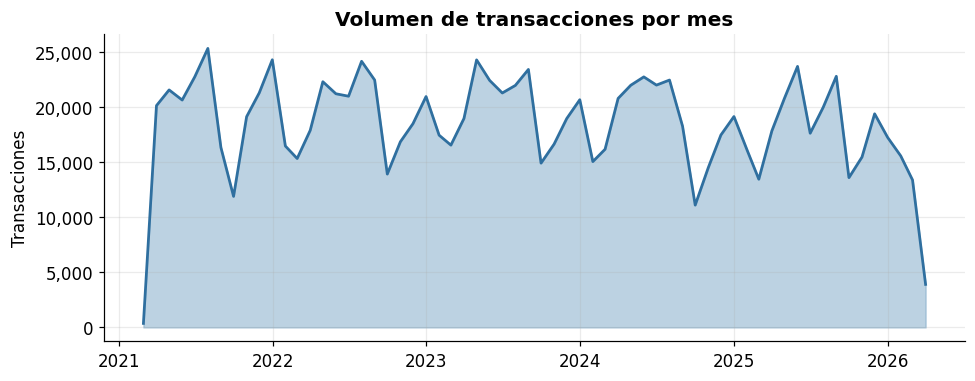

In [14]:
# Volumen mensual de transacciones
vm = expl.set_index('t_timestamp').resample('ME').size()
fig,ax=plt.subplots(figsize=(9,3.6))
ax.fill_between(vm.index, vm.values, color=AZ2, alpha=.5); ax.plot(vm.index, vm.values, color=AZ, lw=1.8)
ax.set_title('Volumen de transacciones por mes'); ax.set_ylabel('Transacciones'); ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f'{int(x):,}'))
fig.savefig(OUT/'exp_volumen_mensual.png', bbox_inches='tight'); plt.show()

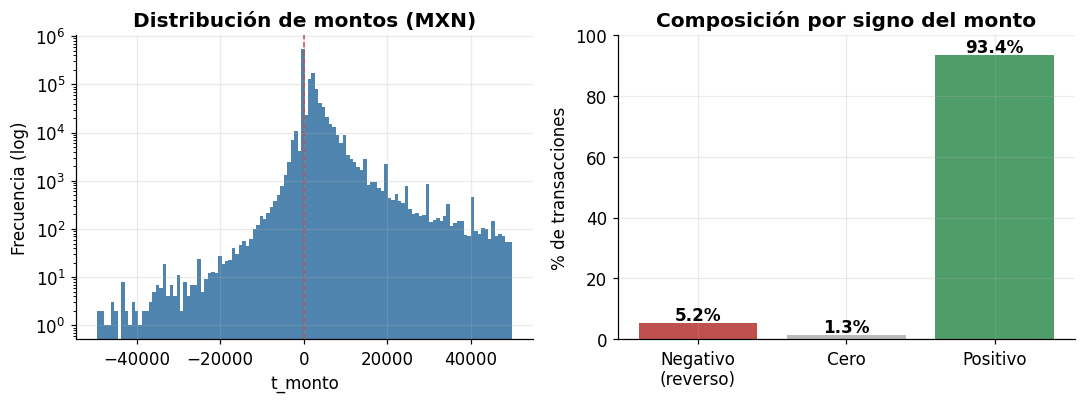

In [15]:
# Distribucion de montos: magnitud (log) y composicion por signo
neg=(monto<0).mean()*100; zero=(monto==0).mean()*100; pos=(monto>0).mean()*100
fig,axes=plt.subplots(1,2,figsize=(10,3.8))
mm=monto[(monto>-50000)&(monto<50000)]
axes[0].hist(mm, bins=120, color=AZ, alpha=.85); axes[0].set_yscale('log')
axes[0].set_title('Distribución de montos (MXN)'); axes[0].set_xlabel('t_monto'); axes[0].set_ylabel('Frecuencia (log)')
axes[0].axvline(0,color=RD,ls='--',lw=1)
axes[1].bar(['Negativo\n(reverso)','Cero','Positivo'],[neg,zero,pos],color=[RD,'#bbbbbb',GR])
axes[1].set_title('Composición por signo del monto'); axes[1].set_ylabel('% de transacciones'); axes[1].set_ylim(0,100)
for i,v in enumerate([neg,zero,pos]): axes[1].text(i,v+1,f'{v:.1f}%',ha='center',fontweight='bold')
fig.savefig(OUT/'exp_distribucion_monto.png', bbox_inches='tight'); plt.show()

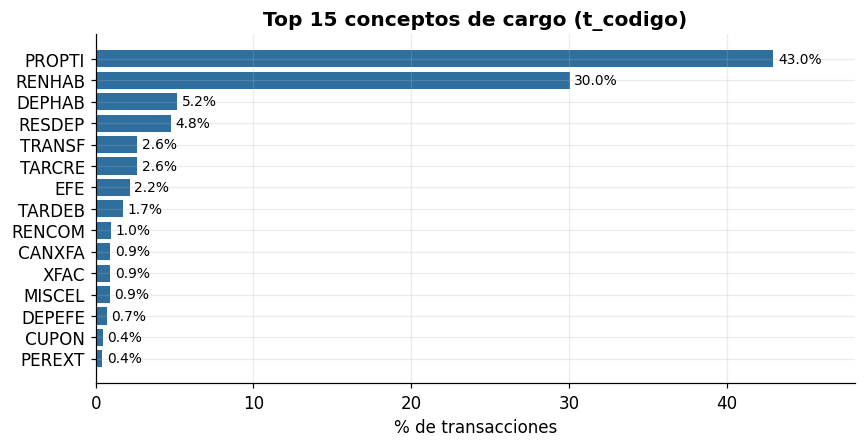

In [16]:
# Top 15 conceptos de cargo
top=expl['t_codigo'].astype('string').str.strip().value_counts(normalize=True).head(15)*100
fig,ax=plt.subplots(figsize=(8,4.2))
ax.barh(top.index[::-1], top.values[::-1], color=AZ)
ax.set_title('Top 15 conceptos de cargo (t_codigo)'); ax.set_xlabel('% de transacciones')
for i,v in enumerate(top.values[::-1]): ax.text(v+0.3,i,f'{v:.1f}%',va='center',fontsize=9)
ax.set_xlim(0,max(top.values)*1.12)
fig.savefig(OUT/'exp_top_conceptos.png', bbox_inches='tight'); plt.show()

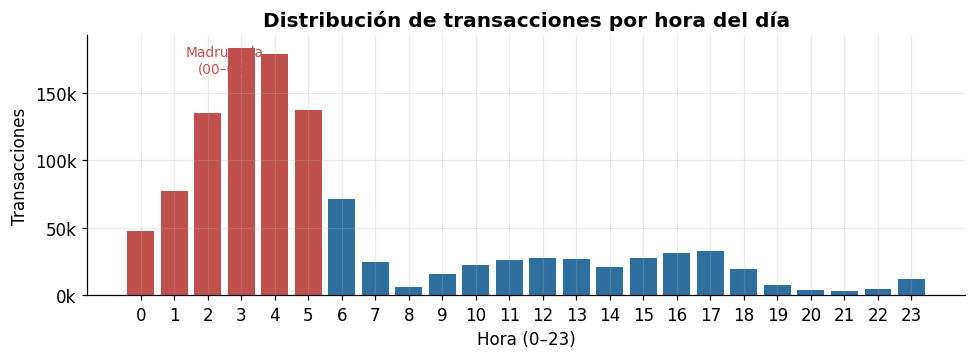

In [17]:
# Distribucion por hora del dia (revela el posteo del night audit)
hr=expl['t_timestamp'].dt.hour.value_counts().sort_index()
fig,ax=plt.subplots(figsize=(9,3.4))
ax.bar(hr.index, hr.values, color=[RD if h<6 else AZ for h in hr.index])
ax.set_title('Distribución de transacciones por hora del día')
ax.set_xlabel('Hora (0–23)'); ax.set_ylabel('Transacciones'); ax.set_xticks(range(0,24))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f'{int(x/1000)}k'))
ax.text(2.5, hr.max()*.9, 'Madrugada\n(00–05)', color=RD, fontsize=9, ha='center')
fig.savefig(OUT/'exp_distribucion_horaria.png', bbox_inches='tight'); plt.show()

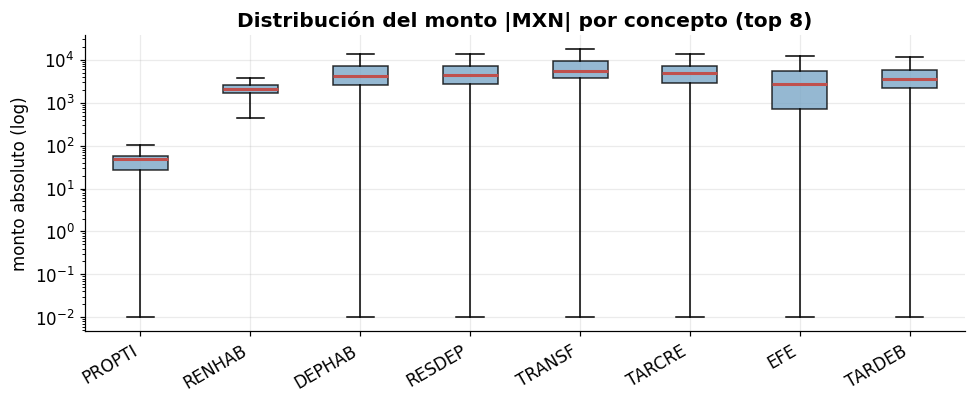

In [18]:
# Monto por concepto (boxplot, escala log)
topc=expl['t_codigo'].astype('string').str.strip().value_counts().head(8).index.tolist()
dd=expl.assign(_c=expl['t_codigo'].astype('string').str.strip(),_m=monto.abs())
dd=dd[dd['_c'].isin(topc)&(dd['_m']>0)]
fig,ax=plt.subplots(figsize=(9,3.8))
bp=ax.boxplot([dd.loc[dd['_c']==c,'_m'].values for c in topc], labels=topc, showfliers=False, patch_artist=True)
for b in bp['boxes']: b.set(facecolor=AZ2, alpha=.8)
for m_ in bp['medians']: m_.set(color=RD, lw=2)
ax.set_yscale('log'); ax.set_title('Distribución del monto |MXN| por concepto (top 8)')
ax.set_ylabel('monto absoluto (log)'); plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
fig.savefig(OUT/'exp_monto_por_concepto.png', bbox_inches='tight'); plt.show()

## Estadísticas

Estadísticos descriptivos (variables numéricas):
              media  mediana     std       min       max
t_monto      1996.8    447.0  5841.5 -936461.0  936461.0
t_impuesto    190.6      0.0   645.9 -149519.0  149519.0
t_propina      17.3      0.0    51.7   -7371.0   14865.0
t_noches        2.1      2.0     2.3       0.0     134.0
h_tfa        2239.4   2093.3   856.9  -15455.0   13265.3
h_tfa_total  6144.8   5616.0  3346.5  -30910.0   62856.3


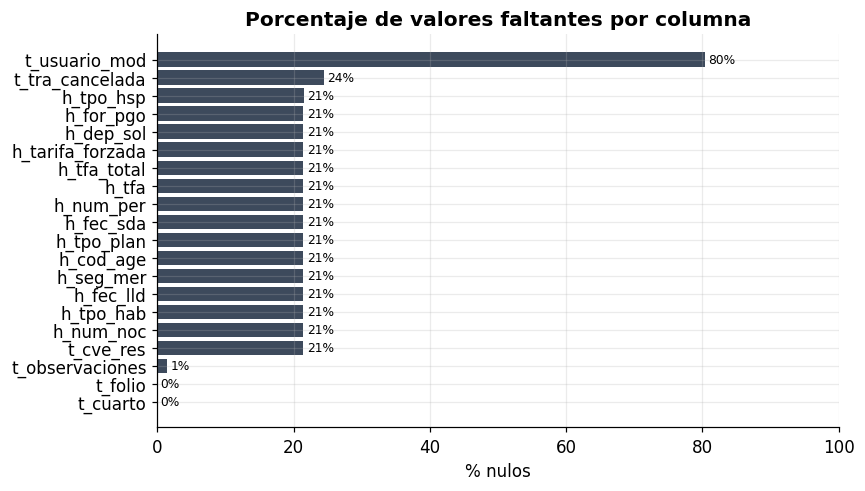


Cobertura de reservación: 78.5%
Cargo vs Abono: {'0': 0.829, '1': 0.171}
Conceptos únicos: 108 | Usuarios: 149


In [19]:
# Estadisticos descriptivos de variables numericas + faltantes
num_cols=['t_monto','t_impuesto','t_propina','t_noches','h_tfa','h_tfa_total']
desc=expl[num_cols].apply(pd.to_numeric, errors='coerce').describe().T[['mean','50%','std','min','max']]
desc.columns=['media','mediana','std','min','max']
print('Estadísticos descriptivos (variables numéricas):'); print(desc.round(1).to_string())

nulos=(expl.isna().mean()*100); nulos=nulos[nulos>0].sort_values()
fig,ax=plt.subplots(figsize=(8,4.6))
ax.barh(nulos.index, nulos.values, color=NV); ax.set_title('Porcentaje de valores faltantes por columna')
ax.set_xlabel('% nulos'); ax.set_xlim(0,100)
for i,v in enumerate(nulos.values): ax.text(v+0.5,i,f'{v:.0f}%',va='center',fontsize=8)
fig.savefig(OUT/'exp_nulos.png', bbox_inches='tight'); plt.show()

print('\nCobertura de reservación:', f"{expl['tiene_reservacion'].mean()*100:.1f}%")
print('Cargo vs Abono:', expl['t_carabo'].value_counts(normalize=True).round(3).to_dict())
print('Conceptos únicos:', expl['t_codigo'].nunique(), '| Usuarios:', expl['t_usuario'].nunique())